Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
GPU: Tesla T4
GPU memory GiB: 14.56
Select IVON_LoRA_Project.zip once for this runtime.


Saving IVON_LoRA_Project.zip to IVON_LoRA_Project.zip

=== install ===
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 122.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 119.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 94.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
install elapsed seconds: 45.8

=== project_install ===
project_install elapsed second

,method,n_seeds,accuracy_mean,accuracy_std,ece_mean,ece_std,nll_mean,nll_std,brier_mean,brier_std,train_seconds_mean,train_seconds_std,prediction_seconds_mean,prediction_seconds_std
0,adamw,3,0.731771,0.017614,0.068863,0.022954,0.680295,0.005350,0.356020,0.003213,49.332126,4.339640,6.798071,0.719257
1,ivon_mean,3,0.721354,0.002255,0.069914,0.002851,0.680130,0.003338,0.364873,0.001583,51.702395,1.112497,7.205077,0.093704
2,ivon_mc,3,0.694010,0.013718,0.179526,0.014866,0.883573,0.040124,0.469428,0.022439,51.702395,1.112497,71.588228,0.385999


,method,metric,mean,std,n_seeds
0,ivon_mean,accuracy,-0.010417,0.019661,3
1,ivon_mean,ece,0.001052,0.023936,3
2,ivon_mean,nll,-0.000165,0.002448,3
3,ivon_mean,brier,0.008853,0.003388,3
4,ivon_mc,accuracy,-0.037760,0.031331,3
5,ivon_mc,ece,0.110664,0.021548,3
6,ivon_mc,nll,0.203278,0.044348,3
7,ivon_mc,brier,0.113408,0.025163,3


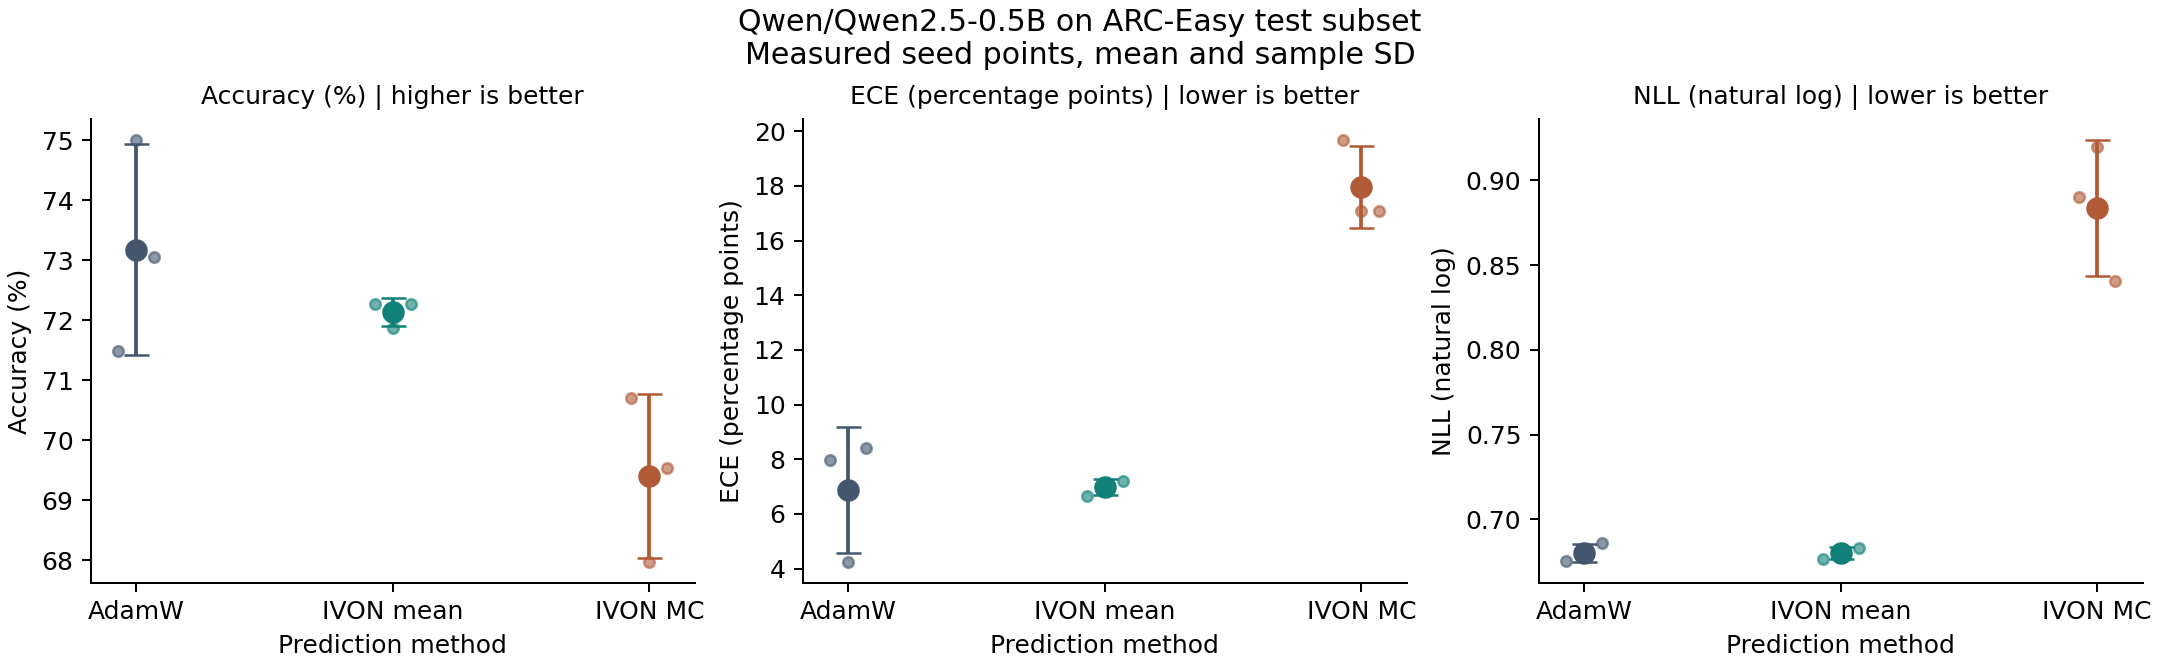

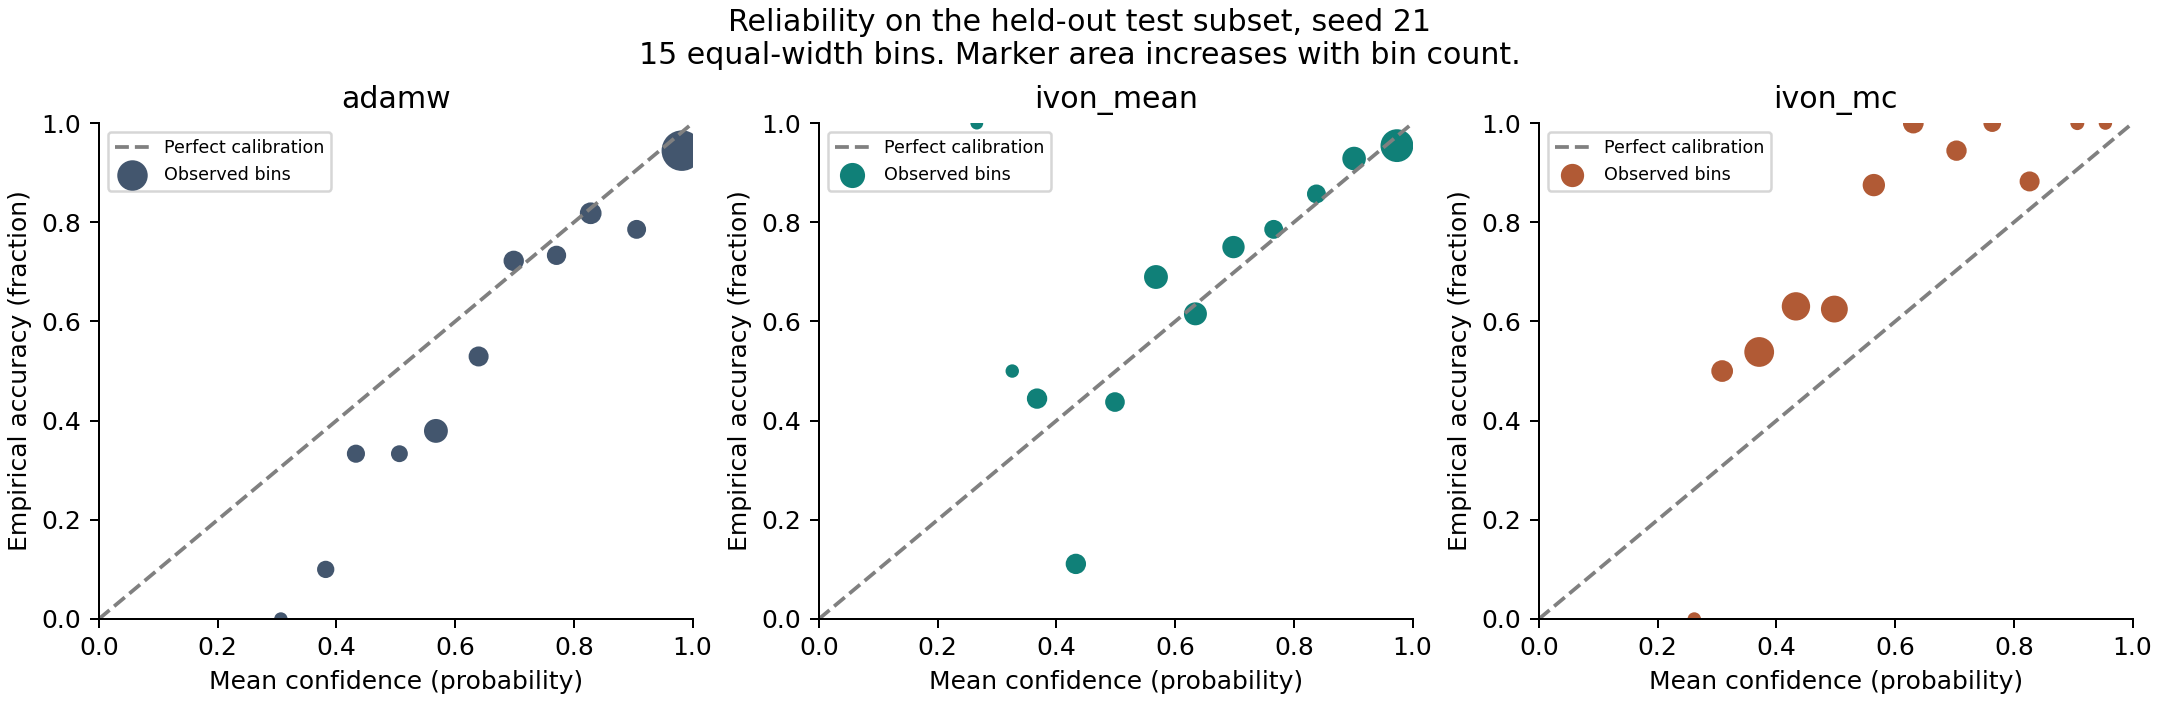

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Finished. Save this executed notebook: File > Download > .ipynb


In [1]:
# IVON-LoRA: verified GPU runner with visible logs and saved evidence
from pathlib import Path
import io, os, sys, subprocess, zipfile, shutil, json, time
from google.colab import files
import torch

print('Python:', sys.version, flush=True)
print('PyTorch:', torch.__version__, flush=True)
assert torch.cuda.is_available(), 'This runtime has no CUDA GPU. Select Runtime > Change runtime type > T4 GPU.'
print('GPU:', torch.cuda.get_device_name(0), flush=True)
print('GPU memory GiB:', round(torch.cuda.get_device_properties(0).total_memory / 2**30, 2), flush=True)
root = Path('/content/ivon_lora_study')
archive_path = Path('/content/IVON_LoRA_Project.zip')
if not (root / 'pyproject.toml').exists():
    if not archive_path.exists():
        print('Select IVON_LoRA_Project.zip once for this runtime.', flush=True)
        uploaded = files.upload()
        assert len(uploaded) == 1, 'Select exactly one project ZIP.'
        name, data = next(iter(uploaded.items()))
        assert name.endswith('.zip')
        archive_path.write_bytes(data)
    root.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path) as archive:
        for entry in archive.infolist():
            assert (root / entry.filename).resolve().is_relative_to(root.resolve()), 'Unsafe archive path'
        archive.extractall(root)
os.chdir(root)
log_dir = root / 'execution_logs'
log_dir.mkdir(exist_ok=True)

def run_logged(label, command):
    print('\n=== ' + label + ' ===', flush=True)
    started = time.perf_counter()
    with (log_dir / (label + '.log')).open('a') as log:
        process = subprocess.Popen(command, cwd=root, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
        try:
            for line in process.stdout:
                print(line, end='', flush=True)
                log.write(line)
                log.flush()
            code = process.wait()
        except BaseException:
            process.terminate()
            process.wait()
            raise
    print(label, 'elapsed seconds:', round(time.perf_counter() - started, 1), flush=True)
    if code:
        raise RuntimeError(label + ' failed. The full error is printed above and saved in execution_logs.')

requirements = [s for s in Path('requirements.txt').read_text().splitlines() if s and not s.startswith(('#', 'torch'))]
run_logged('install', [sys.executable, '-m', 'pip', 'install', '-q', *requirements])
run_logged('project_install', [sys.executable, '-m', 'pip', 'install', '-q', '-e', '.'])
run_logged('correctness_tests', [sys.executable, '-u', '-m', 'pytest', '-q'])
run_logged('gpu_smoke', [sys.executable, '-u', '-m', 'ivon_lora.train', '--config', 'configs/smoke.json', '--output', 'runs/smoke'])
print('Starting MAIN experiment: seeds 21, 42, 87; AdamW and IVON; 128 steps each.', flush=True)
run_logged('three_seed_training', [sys.executable, '-u', '-m', 'ivon_lora.train', '--config', 'configs/quick.json', '--output', 'runs/quick'])
from IPython.display import display, Image
import pandas as pd
summary = root / 'runs/quick/summary'
print('\nMEASURED THREE-SEED RESULTS', flush=True)
display(pd.read_csv(summary / 'comparison.csv'))
display(pd.read_csv(summary / 'paired_deltas.csv'))
display(Image(filename=str(summary / 'comparison.png')))
display(Image(filename=str(summary / 'reliability.png')))
result_zip = shutil.make_archive('/content/ivon_lora_measured_results', 'zip', root / 'runs/quick')
files.download(result_zip)
print('Finished. Save this executed notebook: File > Download > .ipynb', flush=True)


ACTUAL THREE-SEED TRAINING DETAILS


,seed,optimizer,steps,train_seconds,seconds_per_step,peak_train_memory_gib,trainable_parameters,total_parameters,first_batch_ce,last_batch_ce
0,21,adamw,128,44.322694,0.346271,2.958671,540672,494573440,0.714353,0.502412
1,21,ivon,128,50.449549,0.394137,2.963901,540672,494573440,1.400832,1.356003
2,42,adamw,128,51.728819,0.404131,2.961426,540672,494573440,0.899174,0.278858
3,42,ivon,128,52.574647,0.410739,2.963900,540672,494573440,1.302835,0.574114
4,87,adamw,128,51.944865,0.405819,2.961426,540672,494573440,0.388577,0.102058
5,87,ivon,128,52.082988,0.406898,2.964324,540672,494573440,1.063515,0.643303


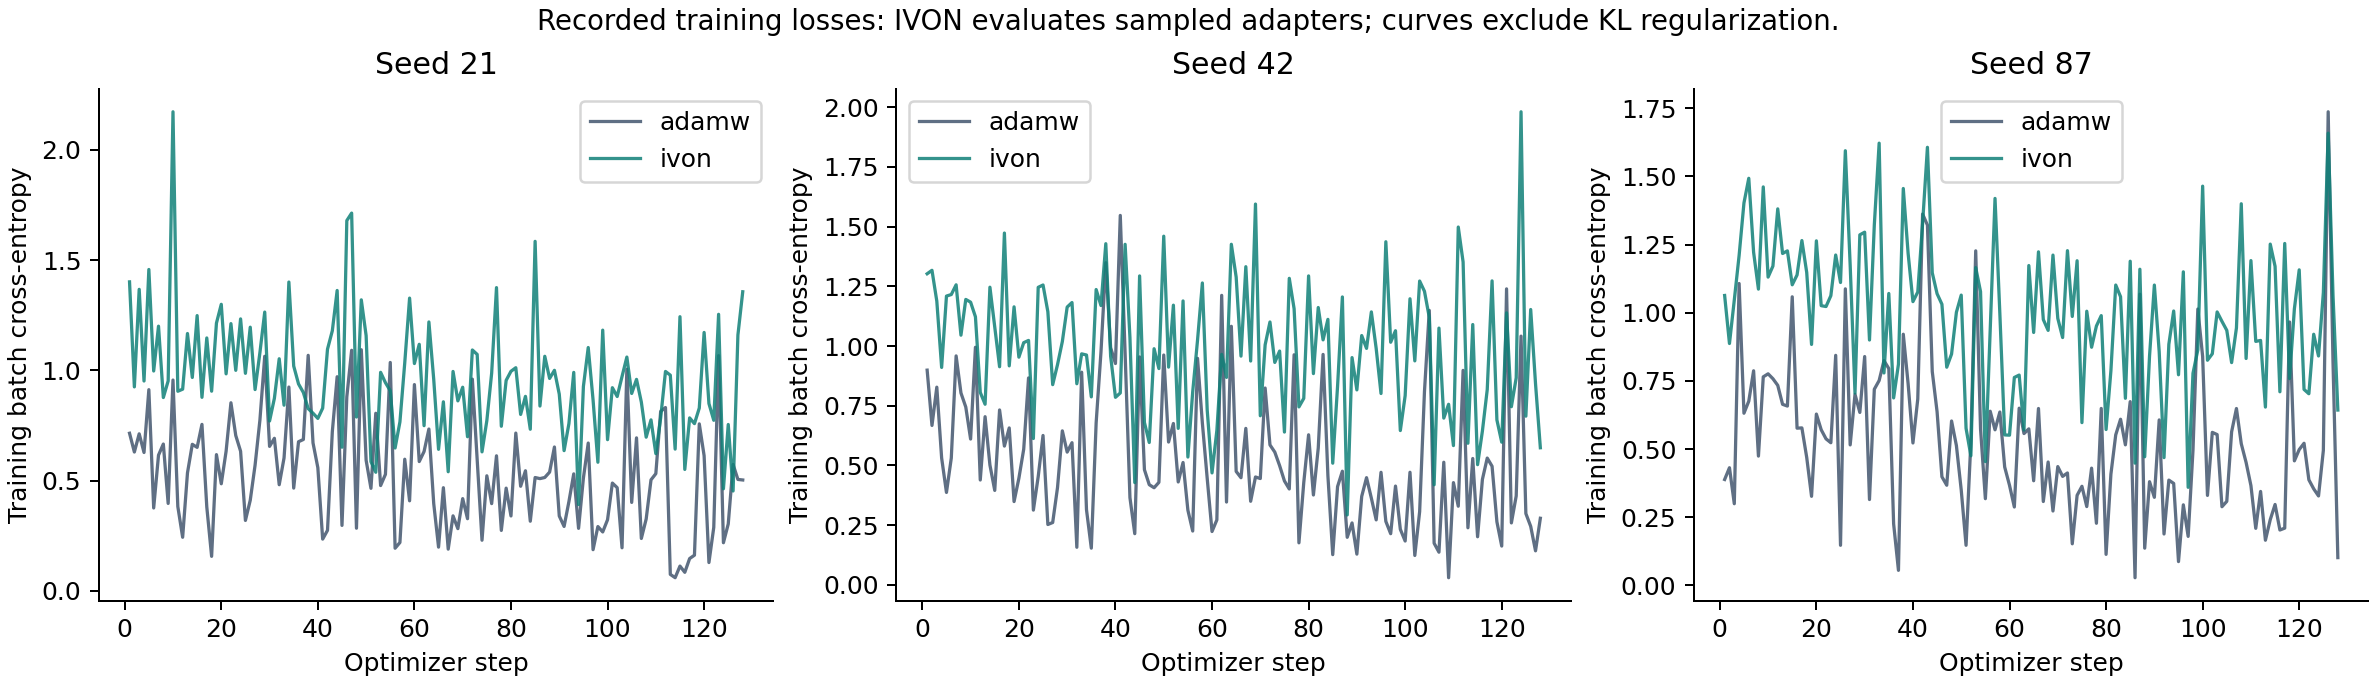

ACTUAL TEST COMPARISON: ECE and accuracy are fractions in this CSV


,method,n_seeds,accuracy_mean,accuracy_std,ece_mean,ece_std,nll_mean,nll_std,brier_mean,brier_std,train_seconds_mean,train_seconds_std,prediction_seconds_mean,prediction_seconds_std
0,adamw,3,0.731771,0.017614,0.068863,0.022954,0.680295,0.005350,0.356020,0.003213,49.332126,4.339640,6.798071,0.719257
1,ivon_mean,3,0.721354,0.002255,0.069914,0.002851,0.680130,0.003338,0.364873,0.001583,51.702395,1.112497,7.205077,0.093704
2,ivon_mc,3,0.694010,0.013718,0.179526,0.014866,0.883573,0.040124,0.469428,0.022439,51.702395,1.112497,71.588228,0.385999


IVON minus AdamW: a negative ECE/NLL delta favors IVON


,method,metric,mean,std,n_seeds
0,ivon_mean,accuracy,-0.010417,0.019661,3
1,ivon_mean,ece,0.001052,0.023936,3
2,ivon_mean,nll,-0.000165,0.002448,3
3,ivon_mean,brier,0.008853,0.003388,3
4,ivon_mc,accuracy,-0.037760,0.031331,3
5,ivon_mc,ece,0.110664,0.021548,3
6,ivon_mc,nll,0.203278,0.044348,3
7,ivon_mc,brier,0.113408,0.025163,3


Runtime environment:
{
  "python": "3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]",
  "torch": "2.11.0+cu128",
  "device": "Tesla T4",
  "cuda": "12.8",
  "option_token_ids": [
    362,
    425,
    356,
    422
  ],
  "packages": {
    "transformers": "4.55.4",
    "peft": "0.17.1",
    "ivon-opt": "0.1.3",
    "datasets": "4.0.0",
    "numpy": "2.0.2"
  }
}
Compact evidence ZIP: IVON_LoRA_Results_For_Professor.zip 756564 bytes
Includes predictions, metrics, data IDs, configuration, training curves and logs. Weights are in the full results archive.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Save the executed notebook using File > Download > .ipynb.


In [2]:
# Training details and a compact archive for the professor and GitHub
from pathlib import Path
import json, csv, zipfile, shutil
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from google.colab import files

run_root = Path('/content/ivon_lora_study/runs/quick')
config = json.loads((run_root / 'config.json').read_text())
seeds = config['seeds']
assert seeds == [21, 42, 87], 'Expected the registered three-seed experiment.'
summary = run_root / 'summary'
assert (summary / 'summary.json').exists(), 'Wait for all main runs to finish.'
fig, axes = plt.subplots(1, len(seeds), figsize=(13.2, 3.8), squeeze=False, constrained_layout=True)
rows = []
for ax, seed in zip(axes[0], seeds):
    for method, color in [('adamw', '#43566e'), ('ivon', '#108078')]:
        folder = run_root / f'seed_{seed}' / method
        info = json.loads((folder / 'complete.json').read_text())
        history = json.loads((folder / 'training_history.json').read_text())
        assert len(history) == config['steps'] == info['steps']
        ax.plot([h['step'] for h in history], [h['loss'] for h in history], label=method, color=color, linewidth=1.3, alpha=.85)
        rows.append({'seed':seed, 'optimizer':method, 'steps':info['steps'], 'train_seconds':info['train_seconds'], 'seconds_per_step':info['train_seconds']/info['steps'], 'peak_train_memory_gib':info['peak_train_memory_gib'], 'trainable_parameters':info['trainable_parameters'], 'total_parameters':info['total_parameters'], 'first_batch_ce':history[0]['loss'], 'last_batch_ce':history[-1]['loss']})
    ax.set(title=f'Seed {seed}', xlabel='Optimizer step', ylabel='Training batch cross-entropy')
    ax.spines[['top','right']].set_visible(False)
    ax.legend()
fig.suptitle('Recorded training losses: IVON evaluates sampled adapters; curves exclude KL regularization.', fontsize=11)
fig.savefig(summary / 'training_curves.png', dpi=180)
plt.close(fig)
details = pd.DataFrame(rows)
details.to_csv(summary / 'training_details.csv', index=False)
print('ACTUAL THREE-SEED TRAINING DETAILS')
display(details)
display(Image(filename=str(summary / 'training_curves.png')))
print('ACTUAL TEST COMPARISON: ECE and accuracy are fractions in this CSV')
display(pd.read_csv(summary / 'comparison.csv'))
print('IVON minus AdamW: a negative ECE/NLL delta favors IVON')
display(pd.read_csv(summary / 'paired_deltas.csv'))
print('Runtime environment:')
print((run_root / 'environment.json').read_text())
shutil.copytree('/content/ivon_lora_study/execution_logs', run_root / 'execution_logs', dirs_exist_ok=True)
compact = Path('/content/IVON_LoRA_Results_For_Professor.zip')
with zipfile.ZipFile(compact, 'w', zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(run_root.rglob('*')):
        if path.is_file() and 'adapter' not in path.relative_to(run_root).parts and path.suffix not in {'.pt', '.safetensors', '.bin'}:
            archive.write(path, path.relative_to(run_root))
print('Compact evidence ZIP:', compact.name, compact.stat().st_size, 'bytes')
print('Includes predictions, metrics, data IDs, configuration, training curves and logs. Weights are in the full results archive.')
files.download(str(compact))
print('Save the executed notebook using File > Download > .ipynb.')
